In [3]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [4]:
df=pd.read_csv("cell_samples.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=699, step=1)
All columns are
0 Clump
1 UnifSize
2 UnifShape
3 MargAdh
4 SingEpiSize
5 BareNuc
6 BlandChrom
7 NormNucl
8 Mit
9 Class


In [3]:
df.shape

(699, 10)

In [4]:
df.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [5]:
df.sample(n=10)

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
436,10,10,10,1,6,1,2,8,1,4
660,1,1,1,1,2,1,2,1,1,2
686,1,1,1,1,2,1,1,1,1,2
688,4,1,1,1,2,1,1,1,1,2
200,9,7,7,5,5,10,7,8,3,4
58,5,2,3,1,6,10,5,1,1,4
551,1,1,1,1,2,1,3,1,1,2
347,1,1,1,1,1,1,1,3,1,2
65,10,4,2,1,3,2,4,3,10,4
468,4,1,1,1,2,1,1,1,1,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Clump        699 non-null    int64 
 1   UnifSize     699 non-null    int64 
 2   UnifShape    699 non-null    int64 
 3   MargAdh      699 non-null    int64 
 4   SingEpiSize  699 non-null    int64 
 5   BareNuc      699 non-null    object
 6   BlandChrom   699 non-null    int64 
 7   NormNucl     699 non-null    int64 
 8   Mit          699 non-null    int64 
 9   Class        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [7]:
df.isnull()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
694,False,False,False,False,False,False,False,False,False,False
695,False,False,False,False,False,False,False,False,False,False
696,False,False,False,False,False,False,False,False,False,False
697,False,False,False,False,False,False,False,False,False,False


In [8]:
print(df.isnull().sum())
print("The data seems to not have any null values")

Clump          0
UnifSize       0
UnifShape      0
MargAdh        0
SingEpiSize    0
BareNuc        0
BlandChrom     0
NormNucl       0
Mit            0
Class          0
dtype: int64
The data seems to not have any null values


In [9]:
df.describe()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BlandChrom,NormNucl,Mit,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [15]:
print('''After analysis we found that the column BareNuc is object type
but that should not be true so we do some data manipulation''')

After analysis we found that the column BareNuc is object type
but that should not be true so we do some data manipulation


In [5]:
#Finding non integer value
for idx, value in enumerate(df['BareNuc']):
    try:
        int(value)
    except (ValueError, TypeError):
        print(f"Non-integer value at index {idx}: {value}")

Non-integer value at index 23: ?
Non-integer value at index 40: ?
Non-integer value at index 139: ?
Non-integer value at index 145: ?
Non-integer value at index 158: ?
Non-integer value at index 164: ?
Non-integer value at index 235: ?
Non-integer value at index 249: ?
Non-integer value at index 275: ?
Non-integer value at index 292: ?
Non-integer value at index 294: ?
Non-integer value at index 297: ?
Non-integer value at index 315: ?
Non-integer value at index 321: ?
Non-integer value at index 411: ?
Non-integer value at index 617: ?


In [9]:
# Lets replace all of them with the mode value 1
rdf = df
rdf['BareNuc'] = rdf['BareNuc'].replace('?', 1)
rdf['BareNuc'] = rdf['BareNuc'].astype(int)
rdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Clump        699 non-null    int64
 1   UnifSize     699 non-null    int64
 2   UnifShape    699 non-null    int64
 3   MargAdh      699 non-null    int64
 4   SingEpiSize  699 non-null    int64
 5   BareNuc      699 non-null    int64
 6   BlandChrom   699 non-null    int64
 7   NormNucl     699 non-null    int64
 8   Mit          699 non-null    int64
 9   Class        699 non-null    int64
dtypes: int64(10)
memory usage: 54.7 KB


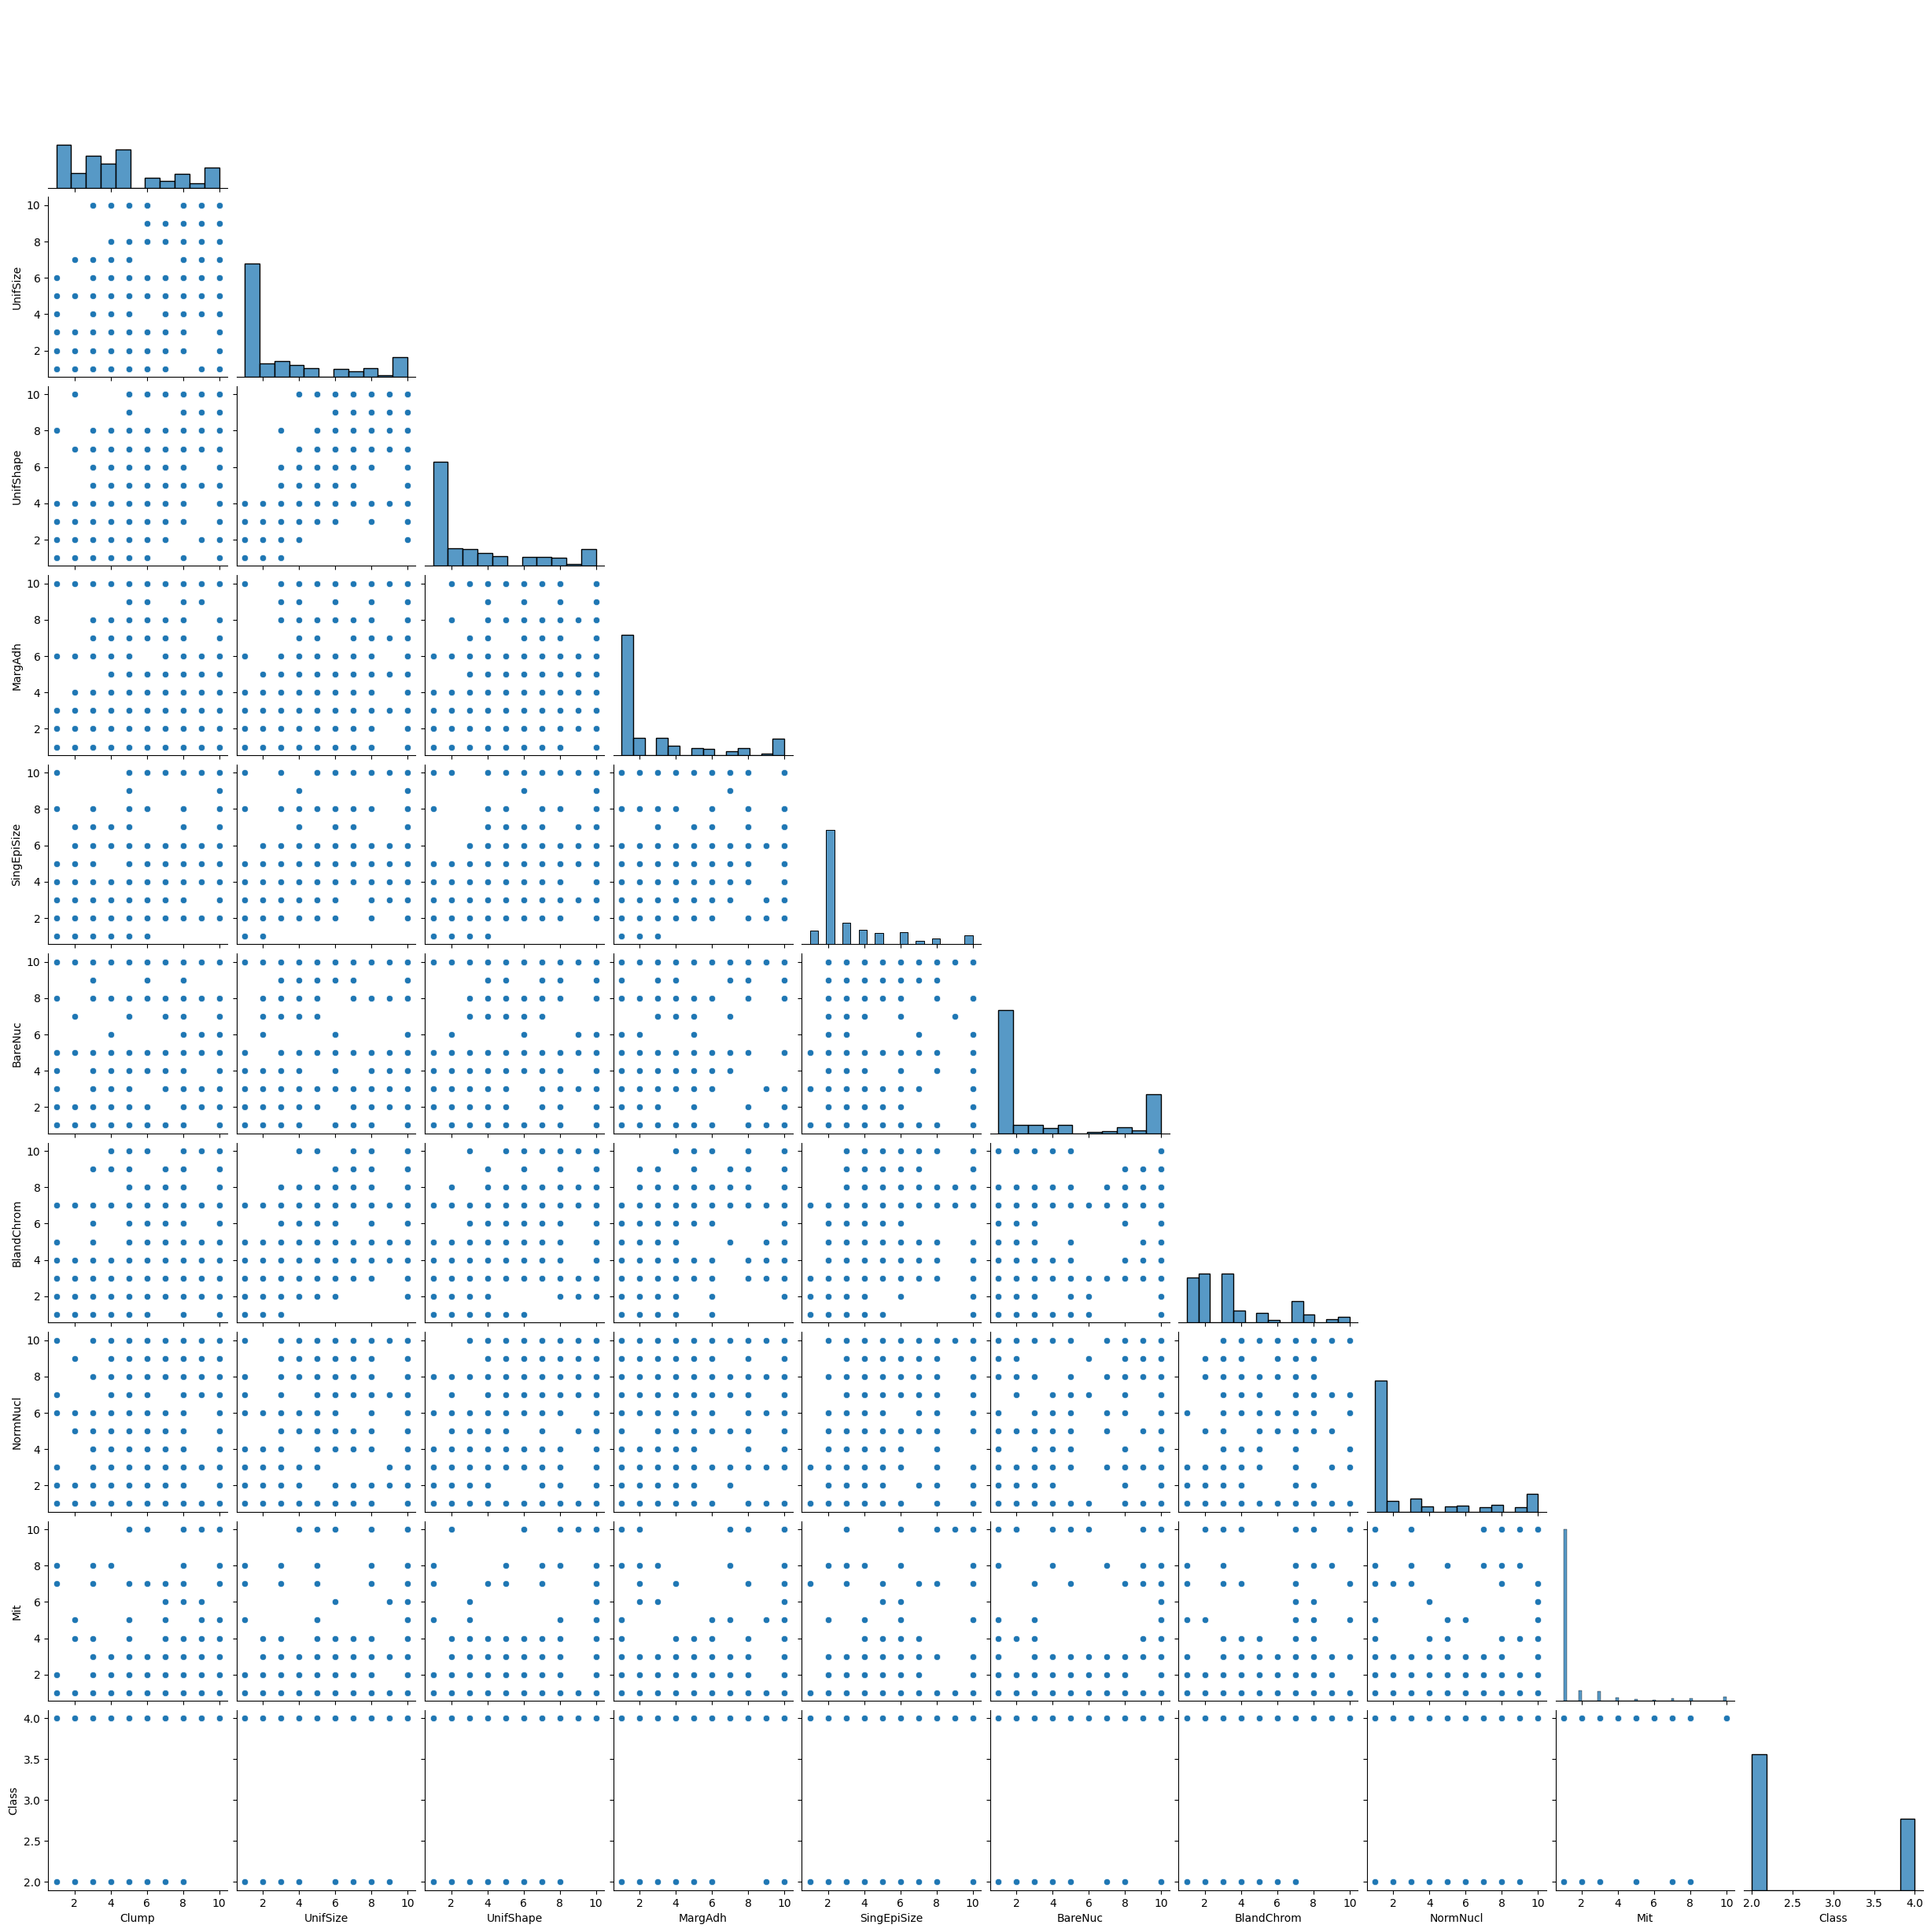

In [10]:
grid = sns.pairplot(rdf,corner=True)

In [11]:
# For saving the plot
'''

grid.savefig('cellpairplot.png', dpi=300, bbox_inches='tight')

'''
print('This plot gives us a rough idea of the data')

This plot gives us a rough idea of the data


<Axes: >

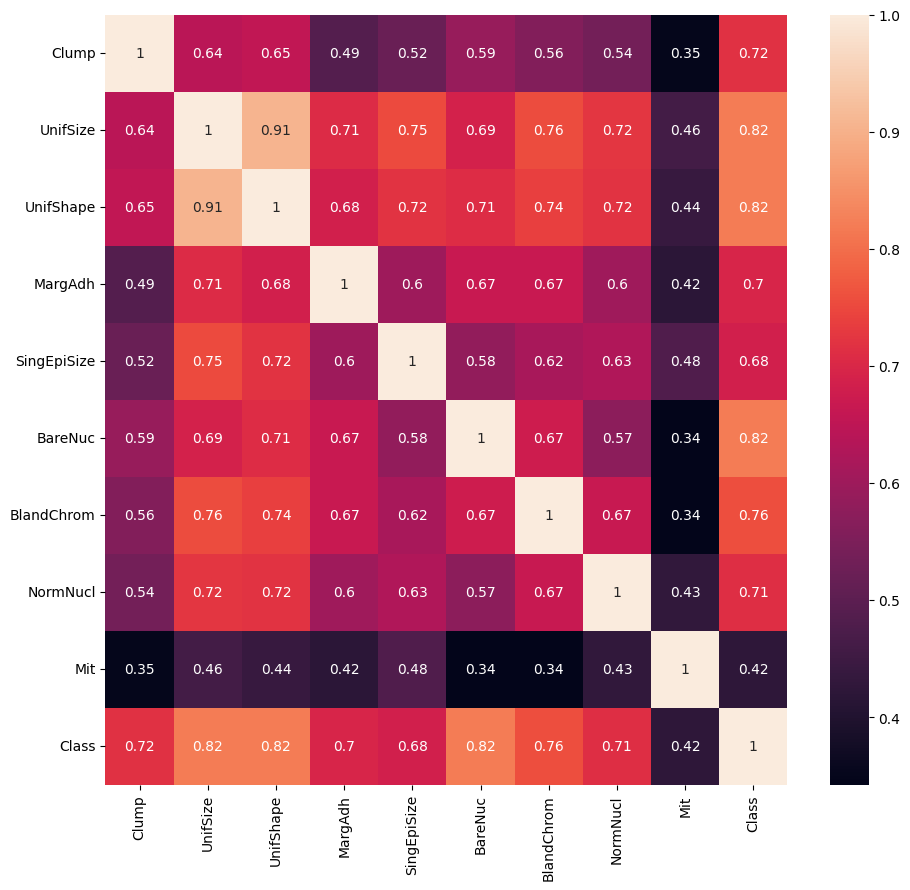

In [12]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)